In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/top_tracks.csv")

df.head()


,year,track_name,artist_name
0,2025,Onça,Gastação Infinita
1,2025,O Trem Azul,Lô Borges
2,2025,Esperar Pra Ver,Evinha
3,2025,Um Girassol Da Cor Do Seu Cabelo,Lô Borges
4,2025,Aranha Caranguejeira,Gastação Infinita


#### Faixas por artistas

In [2]:
df["artist_name"].value_counts().head(50)

artist_name
Dead Fish                           78
Mukeka di Rato                      35
Sérgio Sampaio                      27
Raul Seixas                         25
Kendrick Lamar                      24
Planet Hemp                         18
Raimundos                           17
Gastação Infinita                   15
Bob Marley & The Wailers            15
Criolo                              15
OMA                                 15
Foo Fighters                        15
CPM 22                              15
Descendents                         14
Turnstile                           14
Misfits                             13
Linkin Park                         12
Black Alien                         12
King Gizzard & The Lizard Wizard    11
Sepultura                           11
MF DOOM                             11
Pense                               11
Los Hermanos                        11
Sex Pistols                         11
Caetano Veloso                      10
Madvillain   

#### Faixas de artistas por ano

In [3]:
df.groupby(["year","artist_name"]).size().sort_values(ascending=False)

year  artist_name   
2016  Dead Fish         26
2022  Raul Seixas       22
2024  Sérgio Sampaio    19
2017  Dead Fish         18
2016  Mukeka di Rato    18
                        ..
2025  Led Zeppelin       1
      Luedji Luna        1
      MF DOOM            1
      Madvillain         1
      Marcelo D2         1
Length: 512, dtype: int64

#### Artistas únicos por ano

In [4]:
df.groupby("year")["artist_name"].nunique()

year
2016    27
2017    47
2018    64
2019    59
2020    47
2021    60
2022    47
2023    53
2024    47
2025    61
Name: artist_name, dtype: int64

In [5]:
matrix = df.pivot_table(
    index="artist_name",
    columns="year",
    values="track_name",
    aggfunc="count",
    fill_value=0
)

artist_totals = df["artist_name"].value_counts()

top_artists = artist_totals[artist_totals >= 5].index

matrix_filtered = matrix.loc[top_artists]

In [6]:
matrix_filtered

year,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
artist_name,,,,,,,,,,
Dead Fish,26,18,7,8,6,9,1,3,0,0
Mukeka di Rato,18,4,4,3,0,2,0,3,1,0
Sérgio Sampaio,0,0,0,0,0,2,5,0,19,1
Raul Seixas,0,0,0,0,0,3,22,0,0,0
Kendrick Lamar,0,2,3,3,4,3,4,5,0,0
Planet Hemp,0,3,1,0,2,1,9,2,0,0
Raimundos,0,3,3,4,1,1,0,3,1,1
Gastação Infinita,0,0,0,0,0,0,0,3,8,4
Bob Marley & The Wailers,0,3,2,1,3,1,0,0,0,5


In [7]:
result = (
    df.groupby(["track_name", "artist_name"])
      .filter(lambda x: x["year"].nunique() >= 3)
      .groupby(["track_name", "artist_name"])["year"]
      .apply(lambda x: sorted(x))
      .reset_index(name="years")
)

result["n_years"] = result["years"].apply(len)

result = result.sort_values("n_years", ascending=False)

result

,track_name,artist_name,years,n_years
40,Siga,Dead Fish,"[2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]",8
6,Bridge Burning,Foo Fighters,"[2016, 2017, 2018, 2019, 2021, 2023]",6
37,Rinha de Magnata,Mukeka di Rato,"[2016, 2017, 2018, 2019, 2021, 2023]",6
42,Umaextrapunkprumextrafunk,Black Alien,"[2017, 2018, 2019, 2020, 2021, 2022]",6
11,Conflito Violento,Ratos De Porão,"[2017, 2018, 2019, 2020, 2021]",5
2,Atordoado,CPM 22,"[2017, 2018, 2019, 2020, 2021]",5
30,Our Town,Sticky Fingers,"[2018, 2019, 2020, 2021, 2022]",5
38,SICKO MODE,Travis Scott,"[2019, 2020, 2021, 2022, 2023]",5
35,Refuse / Resist,Sepultura,"[2020, 2021, 2022, 2023, 2025]",5
41,Tão Iguais,Dead Fish,"[2016, 2017, 2018, 2019, 2020]",5


In [12]:
import pandas as pd

df = pd.read_csv("../data/raw/top_tracks.csv")

matrix = df.assign(present=1).pivot_table(
    index=["track_name","artist_name"],
    columns="year",
    values="present",
    aggfunc="max",
    fill_value=0
)

matrix = matrix[matrix.sum(axis=1) >= 3]
matrix = matrix.loc[matrix.sum(axis=1).sort_values(ascending=False).index]

matrix.head()

,year,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
track_name,artist_name,,,,,,,,,,
Siga,Dead Fish,1,1,1,1,1,1,1,1,0,0
Bridge Burning,Foo Fighters,1,1,1,1,0,1,0,1,0,0
Rinha de Magnata,Mukeka di Rato,1,1,1,1,0,1,0,1,0,0
Umaextrapunkprumextrafunk,Black Alien,0,1,1,1,1,1,1,0,0,0
Conflito Violento,Ratos De Porão,0,1,1,1,1,1,0,0,0,0


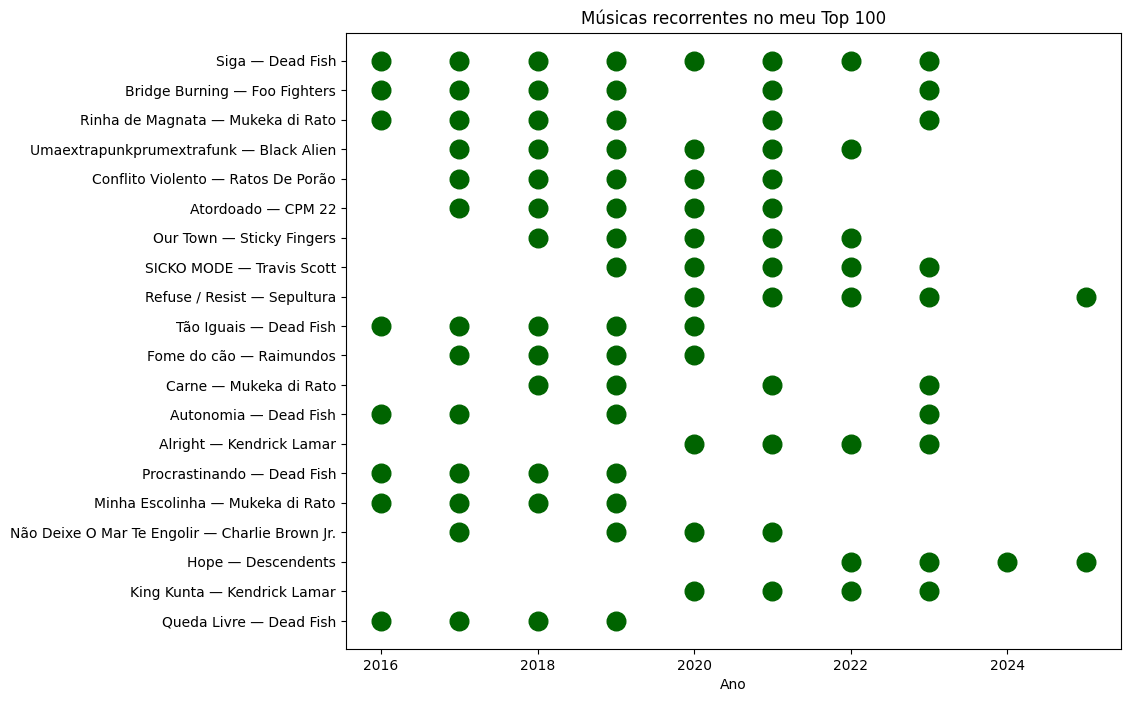

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/top_tracks.csv")

timeline = (
    df.assign(present=1)
      .pivot_table(
          index=["track_name","artist_name"],
          columns="year",
          values="present",
          aggfunc="max",
          fill_value=0
      )
)

timeline = timeline[timeline.sum(axis=1) >= 3]
timeline = timeline.loc[timeline.sum(axis=1).sort_values(ascending=False).index]
timeline = timeline.head(20)

labels = [f"{track} — {artist}" for track, artist in timeline.index]

plt.figure(figsize=(10,8))

for i, row in enumerate(timeline.values):
    years = timeline.columns[row == 1]
    plt.scatter(years, [i]*len(years), s=180, color="darkgreen")

plt.yticks(range(len(labels)), labels)

plt.xlabel("Ano")
plt.title("Músicas recorrentes no meu Top 100")

plt.gca().invert_yaxis()

plt.show()

### Observações iniciais

Esse gráfico mostra as músicas que apareceram **pelo menos 3 vezes** no meu Top 100 anual (2016–2025).

Alguns pontos que chamam atenção:

**1. Existem alguns “clássicos pessoais”.**

Algumas músicas aparecem em muitos anos diferentes.  
O caso mais claro é **Siga (Dead Fish)**, que aparece praticamente em todos os anos analisados.

Outras com alta recorrência:

- Bridge Burning (Foo Fighters)  
- Rinha de Magnata (Mukeka di Rato)  
- Umaextrapunkprumextrafunk (Black Alien)  

Isso sugere um **núcleo relativamente estável do meu gosto musical**.

---

**2. Existe um período mais consistente entre 2017 e 2021.**

Muitas músicas recorrentes aparecem concentradas nesses anos.  
Pode indicar uma fase mais consolidada de preferências.

---

**3. Nos anos mais recentes (2024–2025) quase não aparecem músicas recorrentes.**

Como o gráfico mostra só músicas com **≥3 aparições**, é interessante notar que **só duas aparecem nesses anos mais recentes**.

Isso pode indicar que estou:

- escutando mais músicas novas
- mudando mais rápido de repertório
- ou passando por uma **transição de preferências**

---

**4. Alguns artistas aparecem várias vezes com músicas diferentes.**

Mesmo olhando rápido já dá pra notar alguns recorrentes:

- Dead Fish  
- Mukeka di Rato  
- Kendrick Lamar  

Ou seja, além de músicas específicas, existe também uma **recorrência forte por artista**.

---

**Próximas análises interessantes**

- artistas que aparecem em **mais anos**
- artistas com **mais músicas diferentes no Top 100**
- quantas músicas do Top 100 **se repetem de um ano para o outro**

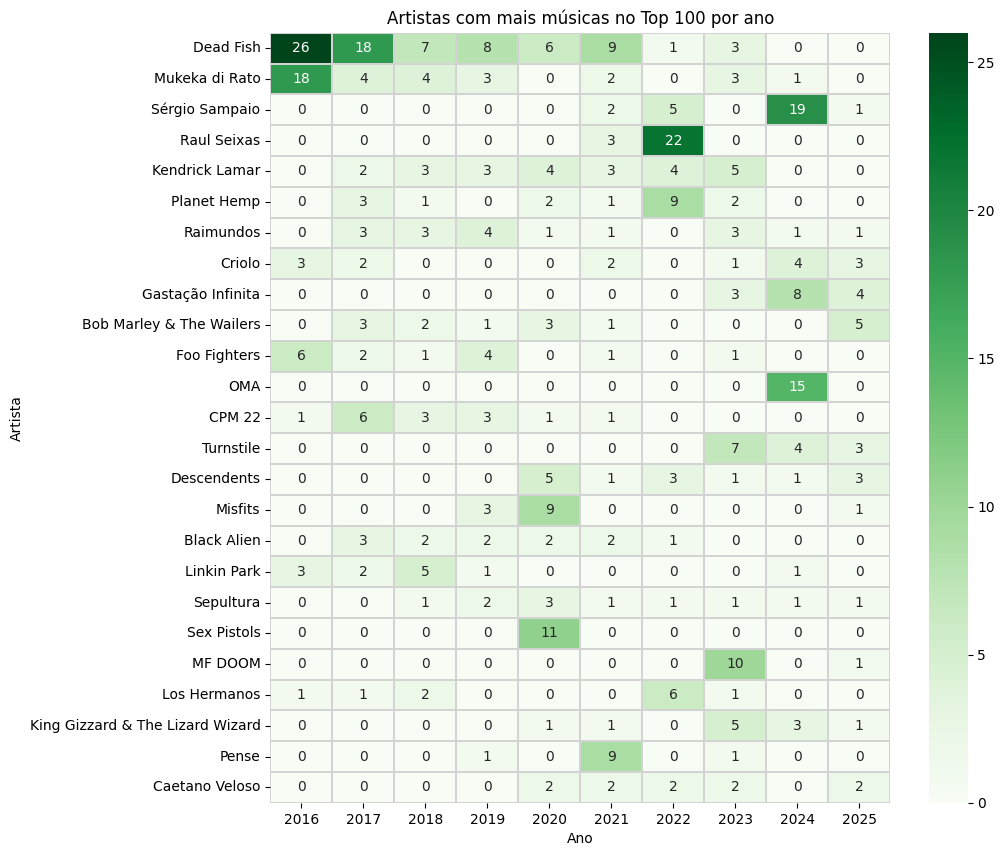

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/top_tracks.csv")

# matriz artista x ano (quantidade de músicas)
artist_matrix = (
    df.groupby(["artist_name","year"])
      .size()
      .unstack(fill_value=0)
)

# ordenar pelos artistas com mais músicas no total
artist_matrix = artist_matrix.loc[
    artist_matrix.sum(axis=1).sort_values(ascending=False).index
]

# limitar para não ficar gigante
artist_matrix = artist_matrix.head(25)

plt.figure(figsize=(10,10))

sns.heatmap(
    artist_matrix,
    cmap="Greens",
    linewidths=0.3,
    linecolor="lightgray",
    annot=True,
    fmt="d"
)

plt.title("Artistas com mais músicas no Top 100 por ano")
plt.xlabel("Ano")
plt.ylabel("Artista")

plt.show()

### Observações sobre recorrência de artistas

Esse gráfico mostra quantas músicas de cada artista apareceram no meu Top 100 em cada ano.

Uma coisa interessante aqui é separar **intensidade** de **consistência**.

Alguns artistas aparecem com muitas músicas, mas concentradas em um único ano.  
Exemplos claros são **Sex Pistols (2020)**, **Raul Seixas (2022)** e **Sérgio Sampaio (2024)**. Isso parece indicar momentos pontuais de exploração: ouvir bastante um artista em um período específico. Raul e Sérgio claramente estão associados aos anos que, junto com a Conchá (banda que participei), fizemos tributos a esses artistas.

Por outro lado, artistas como **Kendrick Lamar**, **Dead Fish** e **Mukeka di Rato** aparecem com menos músicas por ano, mas em vários anos diferentes. Isso sugere um gosto mais **consolidado ao longo do tempo**.

Ou seja, ter muitas músicas em um único ano não necessariamente significa preferência, e sim uma fase.

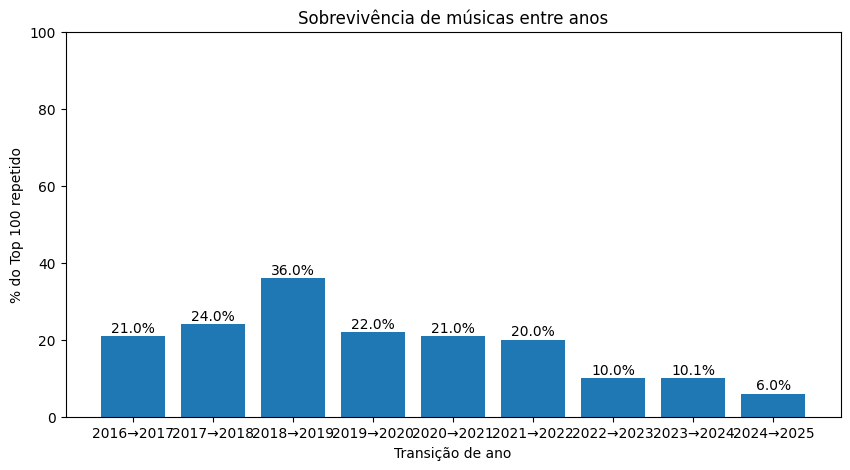

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/top_tracks.csv")

# criar identificador único da música
df["track_id"] = df["track_name"] + " — " + df["artist_name"]

years = sorted(df["year"].unique())

tracks_by_year = {
    y: set(df[df.year == y]["track_id"])
    for y in years
}

data = []

for i in range(1, len(years)):

    prev_year = years[i-1]
    year = years[i]

    prev_tracks = tracks_by_year[prev_year]
    current_tracks = tracks_by_year[year]

    repeated = len(prev_tracks & current_tracks)

    data.append({
        "year_transition": f"{prev_year}→{year}",
        "repeated_tracks": repeated,
        "percent": repeated / len(current_tracks) * 100
    })

result = pd.DataFrame(data)

# gráfico
plt.figure(figsize=(10,5))

bars = plt.bar(result["year_transition"], result["percent"])

plt.ylabel("% do Top 100 repetido")
plt.xlabel("Transição de ano")
plt.title("Sobrevivência de músicas entre anos")

# colocar valores nas barras
for bar, value in zip(bars, result["percent"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.ylim(0,100)

plt.show()